# LightGBM Stage 1 — Hyperparameter optimisation via 5-fold spatial CV

Tunes the four most influential LightGBM hyperparameters of the
Stage 1 binary wet/dry classifier on the **same canonical 5-fold spatial
partition** that is used for the Stage 2 evaluation in
[lgbm_train.ipynb](lgbm_train.ipynb) and the kriging CV in Chapter 4.
Replaces the implicit "defaults that worked" choice of
[lgbm_stage1.ipynb](lgbm_stage1.ipynb) with an honest grid search whose
selection criterion is the mean ROC-AUC across the five folds.

**Pipeline**
1. Load all station-day records and attach the canonical fold ID from
   `s3://thesis-data-ismaktam/lgbm/fold_assignment.parquet`.
2. Per fold $k$, compute the six Stage-1 features leak-free: the
   $K = 50$ nearest neighbours and `global_wet_frac` are pooled from the
   four other folds only.
3. Grid: Tyralis et al. (2023) Table 2 — `max_depth`, `num_leaves`,
   `learning_rate`, `min_child_samples`, filtered by
   `num_leaves <= 2^max_depth`. After filtering: **240 combinations**.
4. For each combination, train on the four training folds and evaluate
   on the held-out fold; repeat for $k = 0, \ldots, 4$. Total trainings:
   $240 \times 5 = 1{,}200$.
5. Aggregate per-combination AUC, F1-wet, F1-dry, Brier as mean $\pm$ std
   across folds; rank by AUC.

**Outputs:**
- `outputs/lgbm/stage1_hpo/grid_results.csv` — full 240-row table
- `outputs/lgbm/stage1_hpo/best_params.json` — top combination
- `outputs/lgbm/stage1_hpo/grid_summary.json` — marginal stats

## 0. Imports + paths

In [1]:
import os, sys, json, time, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import boto3
from sklearn.metrics import roc_auc_score, brier_score_loss, f1_score
from sklearn.neighbors import BallTree

warnings.filterwarnings('ignore')

ROOT = Path('../..')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform, IndicatorTransform
from thesis.transforms.pipeline import TransformPipeline

print(f'Working dir: {Path.cwd()}')
print(f'LightGBM:    {lgb.__version__}')

Working dir: /root/precip_interpolation_thesis
LightGBM:    4.5.0


In [4]:
S3_BUCKET = 'thesis-data-ismaktam'
S3_FOLD   = 'lgbm/fold_assignment.parquet'

OUT_DIR    = Path('outputs/lgbm/stage1_hpo')
OUT_DIR.mkdir(parents=True, exist_ok=True)
FEAT_CACHE = OUT_DIR / 'fold_features.parquet'
ARRAYS_DIR = OUT_DIR / 'fold_arrays'   # pre-staged per-fold .npy memmaps
ARRAYS_DIR.mkdir(parents=True, exist_ok=True)
GRID_OUT   = OUT_DIR / 'grid_results.csv'
BEST_OUT   = OUT_DIR / 'best_params.json'
SUMMARY_OUT = OUT_DIR / 'grid_summary.json'

# Stage 1 design constants (must match lgbm_stage1.ipynb)
K_NEIGHBORS        = 50
WET_THRESHOLD_MM   = 0.5    # observation threshold for the indicator label
DECISION_THRESHOLD = 0.50   # F1 evaluation threshold (operational pipeline uses 0.40)
TARGET_COL         = 'rain_indicator'
FEATURE_COLS       = ['x_proj', 'y_proj', 'elevation_m',
                       'global_wet_frac', 'knn_wet_frac', 'knn_mean_dist_km']

# Tyralis et al. (2023) Table 2 grid
GRID_MAX_DEPTH         = [6, 8, 10]
GRID_NUM_LEAVES        = [100, 200, 500]
GRID_LEARNING_RATE     = [0.05, 0.1]
GRID_MIN_CHILD_SAMPLES = [100, 200,]
HPO_ROUNDS             = 400
EARLY_STOP             = 20

# Device + parallelism: Stage 1 has only 6 features and a binary
# objective — LightGBM CPU is faster than GPU here (GPU overhead per
# training exceeds the speedup at such low feature dimensionality).
#
# We parallelise at the (combo, fold) granularity (1200 tasks). Per-fold
# arrays are pre-staged to disk as .npy memmaps so workers mmap them
# instead of receiving a pickled DataFrame copy each — this is what lets
# the loop scale to all cores on Vast.ai without blowing up memory.
DEVICE                 = 'cpu'
N_WORKERS              = max(1, os.cpu_count() or 4)   # all cores
LGB_THREADS_PER_WORKER = 1                             # 1 task per core

print(f'Device:   {DEVICE}')
print(f'Workers:  {N_WORKERS}  (x{LGB_THREADS_PER_WORKER} threads each)')

s3 = boto3.client('s3')

Device:   cpu
Workers:  255  (x1 threads each)


## 1. Load data + fold assignment

The canonical fold assignment lives on S3 (`lgbm/fold_assignment.parquet`).
It maps every train-station ID to one of five folds. Holdout stations are
absent from the file and are excluded automatically below.

In [5]:
cfg      = Config()
registry = DataRegistry.from_config(cfg)

print('Loading station data (excluding holdout) ...')
raw      = registry.stations.load(cfg.date_start, cfg.date_end, exclude_holdout=True)
pipeline = TransformPipeline([
    ProjectionTransform(target_crs=cfg.study_area.target_crs),
    IndicatorTransform(threshold_mm=WET_THRESHOLD_MM),
])
df = pipeline.fit_transform(raw)
print(f'Records: {len(df):,}  |  stations: {df["station_id"].nunique()}')

fold_local = OUT_DIR / 'fold_assignment.parquet'
if not fold_local.exists():
    s3.download_file(S3_BUCKET, S3_FOLD, str(fold_local))
    print(f'  ↓ s3://{S3_BUCKET}/{S3_FOLD}')
fold_df = pd.read_parquet(fold_local)
df = df.merge(fold_df, on='station_id', how='inner')
print(f'After fold merge: {len(df):,}  |  folds: {sorted(df["fold"].unique())}')

Loading station data (excluding holdout) ...
Records: 45,237,660  |  stations: 1966
After fold merge: 45,237,660  |  folds: [0, 1, 2, 3, 4]


## 2. Per-fold leakage-free feature computation

Mirrors `compute_fold_features()` of `lgbm_stage1.ipynb`. The neighbour
pool and the global_wet_frac denominator both use **training-fold
stations only** for each fold, so the test-fold features cannot leak
information from the held-out fold into the model.

In [6]:
df_clean = df.dropna(subset=['x_proj', 'y_proj', 'elevation_m']).copy()
print(f'After NaN-drop on spatial features: {len(df_clean):,}')

full_pivot = (
    df_clean[['date', 'station_id', TARGET_COL]]
    .pivot_table(index='date', columns='station_id', values=TARGET_COL, aggfunc='first')
)
print(f'Pivot shape: {full_pivot.shape}')


def compute_fold_features(df_clean, fold_id, full_pivot, k=K_NEIGHBORS):
    """Same logic as lgbm_stage1.ipynb::compute_fold_features."""
    train_mask = df_clean['fold'] != fold_id
    train_meta = (df_clean[train_mask].drop_duplicates('station_id')
                  [['station_id', 'x_proj', 'y_proj']].reset_index(drop=True))
    all_meta   = (df_clean.drop_duplicates('station_id')
                  [['station_id', 'x_proj', 'y_proj', 'fold']].reset_index(drop=True))

    train_sids       = set(train_meta['station_id'])
    train_sid_to_idx = {sid: i for i, sid in enumerate(train_meta['station_id'])}
    pivot_train      = full_pivot[[c for c in full_pivot.columns if c in train_sids]]
    gwf              = pivot_train.mean(axis=1)

    tree = BallTree(train_meta[['x_proj', 'y_proj']].values, metric='euclidean')
    tr_dists, tr_idxs  = tree.query(train_meta[['x_proj', 'y_proj']].values, k=k + 1)
    all_dists, all_idxs = tree.query(all_meta[['x_proj', 'y_proj']].values,   k=k)

    n_all   = len(all_meta)
    n_dates = len(pivot_train)
    wet_mat = np.zeros((n_all, n_dates), dtype=np.float32)
    dist_km = np.zeros(n_all,            dtype=np.float32)
    for i in range(n_all):
        sid = all_meta.loc[i, 'station_id']
        if sid in train_sid_to_idx:
            tr_i      = train_sid_to_idx[sid]
            mask_self = tr_dists[tr_i] > 1.0
            nbr_ids   = train_meta['station_id'].values[tr_idxs[tr_i][mask_self]][:k]
            nbr_d     = tr_dists[tr_i][mask_self][:k]
        else:
            nbr_ids = train_meta['station_id'].values[all_idxs[i]]
            nbr_d   = all_dists[i]
        valid_cols = [s for s in nbr_ids if s in pivot_train.columns]
        if valid_cols:
            wet_mat[i] = pivot_train[valid_cols].mean(axis=1).values
        dist_km[i] = nbr_d.mean() / 1000

    knn_wet = (pd.DataFrame(wet_mat.T, index=pivot_train.index,
                              columns=all_meta['station_id'].values)
                  .reset_index().melt(id_vars='date', var_name='station_id',
                                       value_name='knn_wet_frac'))
    knn_d   = pd.DataFrame({'station_id': all_meta['station_id'].values,
                              'knn_mean_dist_km': dist_km})
    gwf_df  = gwf.reset_index(); gwf_df.columns = ['date', 'global_wet_frac']

    out = (df_clean
           .merge(gwf_df,  on='date',                  how='left')
           .merge(knn_wet, on=['date', 'station_id'], how='left')
           .merge(knn_d,   on='station_id',            how='left'))
    out['fold_for_test'] = fold_id   # mark which fold these features were built for
    return out


if FEAT_CACHE.exists():
    print(f'Loading cached fold features: {FEAT_CACHE}')
    df_feat = pd.read_parquet(FEAT_CACHE)
else:
    rows = []
    for k in range(5):
        t0 = time.time()
        rows.append(compute_fold_features(df_clean, k, full_pivot))
        print(f'  fold {k}: features built in {time.time() - t0:.1f}s')
    df_feat = pd.concat(rows, ignore_index=True)
    df_feat.to_parquet(FEAT_CACHE, index=False)
    print(f'Saved: {FEAT_CACHE}  ({df_feat.shape})')

After NaN-drop on spatial features: 45,237,660
Pivot shape: (23010, 1966)
Loading cached fold features: outputs/lgbm/stage1_hpo/fold_features.parquet


## 3. Hyperparameter grid

Same Tyralis et al. (2023) grid as the Stage 2 HPO
([lgbm_hpo.ipynb](lgbm_hpo.ipynb)). The `num_leaves <= 2^max_depth`
filter reduces the 315 cartesian combinations to **240 valid** ones.

In [7]:
valid_combos = [
    (d, l, lr, m)
    for d, l, lr, m in itertools.product(
        GRID_MAX_DEPTH, GRID_NUM_LEAVES,
        GRID_LEARNING_RATE, GRID_MIN_CHILD_SAMPLES
    )
    if l <= 2 ** d
]
print(f'Valid combinations: {len(valid_combos)}')
print(f'Total trainings:    {len(valid_combos)} × 5 folds = {len(valid_combos) * 5}')

Valid combinations: 20
Total trainings:    20 × 5 folds = 100


## 4. Main HPO loop

Per combination $c$ and fold $k$: train on rows where `fold_for_test = k`
and `fold != k` (i.e. the four training folds with their fold-$k$
features), evaluate on rows where `fold_for_test = k` and `fold = k`
(the held-out fold). Early stopping uses the held-out fold as the
validation set.

In [8]:
from joblib import Parallel, delayed
import gc

# --- Pre-stage per-fold (X_tr, y_tr, X_te, y_te) arrays as .npy on disk.
# Workers will np.load(..., mmap_mode='r') so the OS pages share one copy
# across all processes instead of every worker pickling df_feat.
needed = []
for k in range(5):
    needed += [f'fold{k}_{n}.npy' for n in ('Xtr', 'ytr', 'Xte', 'yte')]
if not all((ARRAYS_DIR / n).exists() for n in needed):
    print('Pre-staging per-fold arrays ...')
    for k in range(5):
        sub   = df_feat[df_feat['fold_for_test'] == k]
        train = sub[sub['fold'] != k]
        test  = sub[sub['fold'] == k]
        np.save(ARRAYS_DIR / f'fold{k}_Xtr.npy', train[FEATURE_COLS].values.astype(np.float32))
        np.save(ARRAYS_DIR / f'fold{k}_ytr.npy', train[TARGET_COL ].values.astype(np.int32))
        np.save(ARRAYS_DIR / f'fold{k}_Xte.npy', test [FEATURE_COLS].values.astype(np.float32))
        np.save(ARRAYS_DIR / f'fold{k}_yte.npy', test [TARGET_COL ].values.astype(np.int32))
        print(f'  fold {k}: train={len(train):,}  test={len(test):,}')
    del df_feat, df_clean, full_pivot
    gc.collect()
else:
    print(f'Per-fold arrays already staged in {ARRAYS_DIR}')

ARRAYS_DIR_STR = str(ARRAYS_DIR.resolve())


def train_eval_one(arrays_dir, fold_id, params, lgb_threads):
    """One (combo, fold) training. Loads fold arrays via mmap."""
    base = Path(arrays_dir)
    X_tr = np.load(base / f'fold{fold_id}_Xtr.npy', mmap_mode='r')
    y_tr = np.load(base / f'fold{fold_id}_ytr.npy', mmap_mode='r')
    X_te = np.load(base / f'fold{fold_id}_Xte.npy', mmap_mode='r')
    y_te = np.load(base / f'fold{fold_id}_yte.npy', mmap_mode='r')

    spw = (y_tr == 0).sum() / max(int((y_tr == 1).sum()), 1)
    full_params = {
        **params,
        'objective':         'binary',
        'metric':            'auc',
        'feature_fraction':  0.8,
        'bagging_fraction':  0.8,
        'bagging_freq':      1,
        'scale_pos_weight':  float(spw),
        'device_type':       'cpu',
        'num_threads':       lgb_threads,
        'verbosity':         -1,
        'seed':              42,
    }
    dtrain = lgb.Dataset(np.ascontiguousarray(X_tr), label=np.asarray(y_tr))
    dval   = lgb.Dataset(np.ascontiguousarray(X_te), label=np.asarray(y_te),
                          reference=dtrain)
    booster = lgb.train(
        full_params, dtrain,
        num_boost_round=HPO_ROUNDS,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                    lgb.log_evaluation(period=-1)],
    )
    p = booster.predict(X_te, num_iteration=booster.best_iteration)
    pred_lbl = (p > DECISION_THRESHOLD).astype(int)
    return {
        'fold':      fold_id,
        'auc':       float(roc_auc_score(y_te, p)),
        'brier':     float(brier_score_loss(y_te, p)),
        'f1_wet':    float(f1_score(y_te, pred_lbl, pos_label=1)),
        'f1_dry':    float(f1_score(y_te, pred_lbl, pos_label=0)),
        'best_iter': int(booster.best_iteration),
    }


def eval_one_combo_fold(arrays_dir, combo_idx, combo, fold_id, lgb_threads):
    d, l, lr, m = combo
    params = {'max_depth': d, 'num_leaves': l,
              'learning_rate': lr, 'min_child_samples': m}
    r = train_eval_one(arrays_dir, fold_id, params, lgb_threads)
    return {'combo_idx': combo_idx, **params, **r}


# Flatten to 1200 (combo, fold) tasks
tasks = [(i, c, k) for i, c in enumerate(valid_combos) for k in range(5)]
t_start = time.time()
print(f'Launching {len(tasks)} tasks ({len(valid_combos)} combos × 5 folds) ...')
print(f'  parallel: {N_WORKERS} workers, each x {LGB_THREADS_PER_WORKER} LightGBM thread(s)')
fold_rows = Parallel(n_jobs=N_WORKERS, backend='loky', verbose=10)(
    delayed(eval_one_combo_fold)(ARRAYS_DIR_STR, i, c, k, LGB_THREADS_PER_WORKER)
    for i, c, k in tasks
)
print(f'Done in {(time.time() - t_start) / 60:.1f} min')

# Aggregate per combo
fold_df_raw = pd.DataFrame(fold_rows)
agg = (fold_df_raw
       .groupby(['combo_idx', 'max_depth', 'num_leaves',
                  'learning_rate', 'min_child_samples'])
       .agg(auc_mean       =('auc',       'mean'),
             auc_std        =('auc',       lambda x: float(np.std(x, ddof=1))),
             brier_mean     =('brier',     'mean'),
             brier_std      =('brier',     lambda x: float(np.std(x, ddof=1))),
             f1_wet_mean    =('f1_wet',    'mean'),
             f1_wet_std     =('f1_wet',    lambda x: float(np.std(x, ddof=1))),
             f1_dry_mean    =('f1_dry',    'mean'),
             f1_dry_std     =('f1_dry',    lambda x: float(np.std(x, ddof=1))),
             best_iter_median=('best_iter', lambda x: int(np.median(x))))
       .reset_index()
       .drop(columns='combo_idx'))

grid_df = agg.sort_values('auc_mean', ascending=False).reset_index(drop=True)
grid_df.to_csv(GRID_OUT, index=False)
fold_df_raw.to_csv(OUT_DIR / 'grid_results_per_fold.csv', index=False)
print(f'Saved: {GRID_OUT}  ({len(grid_df)} rows)')
print(f'Saved: {OUT_DIR / "grid_results_per_fold.csv"}  ({len(fold_df_raw)} rows)')
grid_df.head(10)

Pre-staging per-fold arrays ...
  fold 0: train=36,171,720  test=9,065,940
  fold 1: train=36,194,730  test=9,042,930
  fold 2: train=36,194,730  test=9,042,930
  fold 3: train=36,194,730  test=9,042,930
  fold 4: train=36,194,730  test=9,042,930
Launching 100 tasks (20 combos × 5 folds) ...
  parallel: 255 workers, each x 1 LightGBM thread(s)


[Parallel(n_jobs=255)]: Using backend LokyBackend with 255 concurrent workers.
[Parallel(n_jobs=255)]: Done   9 out of 100 | elapsed:  4.8min remaining: 48.3min
[Parallel(n_jobs=255)]: Done  20 out of 100 | elapsed:  4.8min remaining: 19.3min
[Parallel(n_jobs=255)]: Done  31 out of 100 | elapsed:  4.9min remaining: 10.8min
[Parallel(n_jobs=255)]: Done  42 out of 100 | elapsed:  5.2min remaining:  7.2min
[Parallel(n_jobs=255)]: Done  53 out of 100 | elapsed:  5.2min remaining:  4.6min
[Parallel(n_jobs=255)]: Done  64 out of 100 | elapsed:  5.3min remaining:  3.0min
[Parallel(n_jobs=255)]: Done  75 out of 100 | elapsed:  5.4min remaining:  1.8min
[Parallel(n_jobs=255)]: Done  86 out of 100 | elapsed:  5.7min remaining:   55.4s
[Parallel(n_jobs=255)]: Done  97 out of 100 | elapsed:  5.8min remaining:   10.7s


Done in 6.0 min
Saved: outputs/lgbm/stage1_hpo/grid_results.csv  (20 rows)
Saved: outputs/lgbm/stage1_hpo/grid_results_per_fold.csv  (100 rows)


[Parallel(n_jobs=255)]: Done 100 out of 100 | elapsed:  6.0min finished


,max_depth,num_leaves,learning_rate,min_child_samples,auc_mean,auc_std,brier_mean,brier_std,f1_wet_mean,f1_wet_std,f1_dry_mean,f1_dry_std,best_iter_median
0,10,500,0.10,100,0.979511,0.000615,0.172817,0.000403,0.654704,0.024347,0.860915,0.007347,2
1,10,500,0.10,200,0.979511,0.000616,0.172817,0.000403,0.654704,0.024347,0.860915,0.007347,2
2,10,500,0.05,200,0.979495,0.000602,0.202181,0.000503,0.000000,0.000000,0.761729,0.002061,2
3,10,500,0.05,100,0.979495,0.000603,0.202181,0.000503,0.000000,0.000000,0.761729,0.002061,2
4,8,200,0.10,200,0.979432,0.000609,0.172877,0.000395,0.673065,0.034069,0.865722,0.009999,2
5,8,200,0.10,100,0.979432,0.000609,0.172877,0.000395,0.673065,0.034069,0.865722,0.009999,2
6,8,200,0.05,100,0.979407,0.000599,0.202214,0.000501,0.000000,0.000000,0.761729,0.002061,2
7,8,200,0.05,200,0.979407,0.000599,0.202214,0.000501,0.000000,0.000000,0.761729,0.002061,2
8,10,200,0.10,100,0.979398,0.000607,0.172858,0.000401,0.667338,0.031798,0.864195,0.009363,2
9,10,200,0.10,200,0.979398,0.000607,0.172858,0.000401,0.667338,0.031798,0.864195,0.009363,2


## 5. Best combination + grid summary

In [9]:
best = grid_df.iloc[0].to_dict()
best_params = {
    'max_depth':         int(best['max_depth']),
    'num_leaves':        int(best['num_leaves']),
    'learning_rate':     float(best['learning_rate']),
    'min_child_samples': int(best['min_child_samples']),
    'auc_cv_mean':       float(best['auc_mean']),
    'auc_cv_std':        float(best['auc_std']),
    'brier_cv_mean':     float(best['brier_mean']),
    'f1_wet_cv_mean':    float(best['f1_wet_mean']),
    'f1_dry_cv_mean':    float(best['f1_dry_mean']),
    'best_iter_median':  int(best['best_iter_median']),
    'source':            'grid_search_tyralis2023_stage1_kfold',
    'n_combos':          len(valid_combos),
    'cv_folds':          5,
    'metric_selection':  'auc_mean',
}
BEST_OUT.write_text(json.dumps(best_params, indent=2))
print(f'Saved: {BEST_OUT}')
print(json.dumps(best_params, indent=2))

summary = {
    'best': best_params,
    'auc': {
        'min':    float(grid_df['auc_mean'].min()),
        'median': float(grid_df['auc_mean'].median()),
        'max':    float(grid_df['auc_mean'].max()),
        'std':    float(grid_df['auc_mean'].std()),
    },
    'marginal_best_auc': {
        axis: {str(v): float(grid_df[grid_df[axis] == v]['auc_mean'].max())
                 for v in sorted(grid_df[axis].unique())}
        for axis in ['max_depth', 'num_leaves', 'learning_rate', 'min_child_samples']
    },
    'marginal_mean_auc': {
        axis: {str(v): float(grid_df[grid_df[axis] == v]['auc_mean'].mean())
                 for v in sorted(grid_df[axis].unique())}
        for axis in ['max_depth', 'num_leaves', 'learning_rate', 'min_child_samples']
    },
    'top10': grid_df.head(10).to_dict(orient='records'),
}
SUMMARY_OUT.write_text(json.dumps(summary, indent=2, default=str))
print(f'Saved: {SUMMARY_OUT}')

Saved: outputs/lgbm/stage1_hpo/best_params.json
{
  "max_depth": 10,
  "num_leaves": 500,
  "learning_rate": 0.1,
  "min_child_samples": 100,
  "auc_cv_mean": 0.9795110504724531,
  "auc_cv_std": 0.0006154047286212181,
  "brier_cv_mean": 0.1728173088469379,
  "f1_wet_cv_mean": 0.6547037112250573,
  "f1_dry_cv_mean": 0.8609148312885393,
  "best_iter_median": 2,
  "source": "grid_search_tyralis2023_stage1_kfold",
  "n_combos": 20,
  "cv_folds": 5,
  "metric_selection": "auc_mean"
}
Saved: outputs/lgbm/stage1_hpo/grid_summary.json


## 6. Quick visualisation

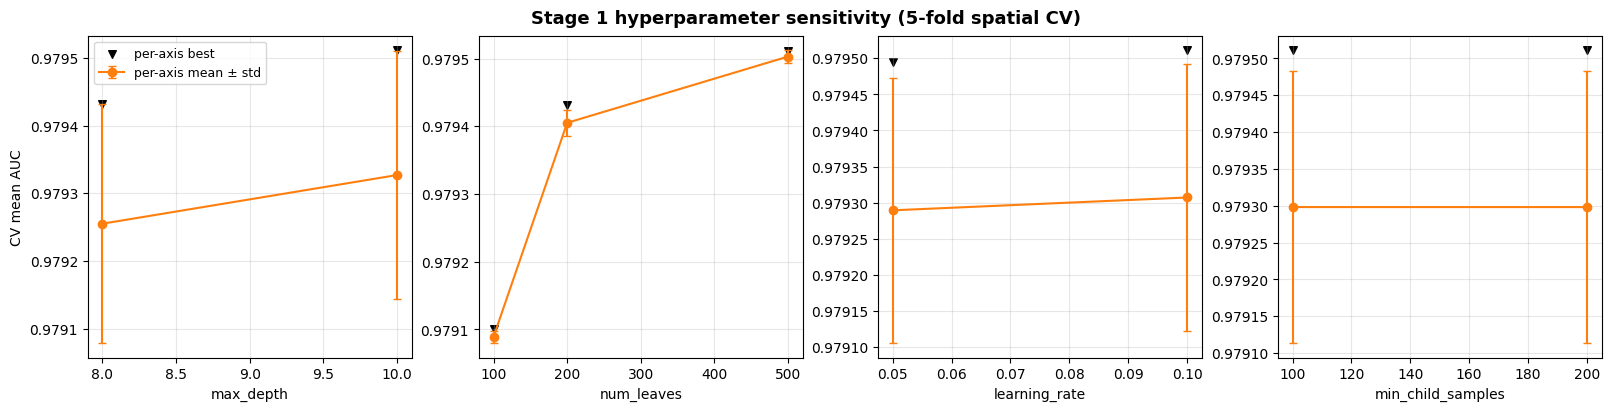

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for ax, axis in zip(axes, ['max_depth', 'num_leaves', 'learning_rate', 'min_child_samples']):
    g = grid_df.groupby(axis)['auc_mean']
    ax.errorbar(g.mean().index, g.mean().values, yerr=g.std().values,
                 fmt='-o', color='tab:orange', capsize=3, label='per-axis mean ± std')
    ax.scatter(g.max().index, g.max().values, color='black', s=30,
                marker='v', label='per-axis best')
    ax.set_xlabel(axis)
    ax.set_ylabel('CV mean AUC' if axis == 'max_depth' else '')
    ax.grid(True, alpha=0.3)
    if axis == 'max_depth':
        ax.legend(fontsize=9)
fig.suptitle('Stage 1 hyperparameter sensitivity (5-fold spatial CV)',
              fontsize=13, fontweight='bold')
fig.savefig(OUT_DIR / 'stage1_hpo_marginals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Upload results to S3 (optional)

In [11]:
S3_OUT = 'lgbm/stage1_hpo'
for local in [GRID_OUT, BEST_OUT, SUMMARY_OUT, OUT_DIR / 'stage1_hpo_marginals.png']:
    try:
        s3.upload_file(str(local), S3_BUCKET, f'{S3_OUT}/{local.name}')
        print(f'  ↑ s3://{S3_BUCKET}/{S3_OUT}/{local.name}')
    except Exception as e:
        print(f'  upload skipped: {local.name} → {e.__class__.__name__}: {e}')

  ↑ s3://thesis-data-ismaktam/lgbm/stage1_hpo/grid_results.csv
  ↑ s3://thesis-data-ismaktam/lgbm/stage1_hpo/best_params.json
  ↑ s3://thesis-data-ismaktam/lgbm/stage1_hpo/grid_summary.json
  ↑ s3://thesis-data-ismaktam/lgbm/stage1_hpo/stage1_hpo_marginals.png
